# Capítulo 5.4 – Resampling Methods: Ejercicios Conceptuales

### Julieta Madrigal Flores - 744029
### Lunes 4 de mayo 2026

# **Parte conceptual**

## Ejercicio 1 – Derivar la fórmula de α

**Contexto:** Invertimos fracción α en activo X y (1−α) en Y. Queremos minimizar el riesgo del portafolio.

**Minimizar:** $f(\alpha) = \text{Var}(\alpha X + (1-\alpha)Y)$

**Paso 1 – Expandir con propiedades de varianza:**

$$f(\alpha) = \alpha^2\sigma_X^2 + (1-\alpha)^2\sigma_Y^2 + 2\alpha(1-\alpha)\sigma_{XY}$$

**Paso 2 – Derivar respecto a α e igualar a cero:**

$$\frac{df}{d\alpha} = 2\alpha\sigma_X^2 - 2\sigma_Y^2 + 2\alpha\sigma_Y^2 + 2\sigma_{XY} - 4\alpha\sigma_{XY} = 0$$

**Paso 3 – Despejar α:**

$$\alpha(2\sigma_X^2 + 2\sigma_Y^2 - 4\sigma_{XY}) = 2\sigma_Y^2 - 2\sigma_{XY}$$

$$\boxed{\alpha = \frac{\sigma_Y^2 - \sigma_{XY}}{\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}}} \quad $$

**Verificación (mínimo):** $\frac{d^2f}{d\alpha^2} = 2(\sigma_X - \sigma_Y)^2 \geq 0$



## Ejercicio 2 – Probabilidades en Bootstrap

**Contexto:** Bootstrap toma n muestras **con reemplazo** de un dataset de tamaño n.

**(a)** P(1ra extracción ≠ obs j) = $1 - \frac{1}{n}$

> Hay n obs equiprobables, solo 1 es la j-ésima.

**(b)** P(2da extracción ≠ obs j) = $1 - \frac{1}{n}$

> Muestreo con reemplazo → extracciones independientes → misma probabilidad.

**(c)** P(obs j no aparece en ninguna de las n extracciones):

$$P(j \notin \text{bootstrap}) = \left(1 - \frac{1}{n}\right)^n$$

**(d, e, f)** Valores numéricos:

Se obtienen aplicando la fórmula $P(j \notin \text{bootstrap}) = (1 - 1/n)^n$ para cada valor de n:

**Para n = 5:**
- $P(\text{no aparezca}) = (1 - 1/5)^5 = (0.8)^5 = 0.32768 \approx 0.3277$
- $P(\text{sí aparezca}) = 1 - 0.32768 = 0.67232 \approx 0.6723$

**Para n = 100:**
- $P(\text{no aparezca}) = (1 - 1/100)^{100} = (0.99)^{100} \approx 0.3660$
- $P(\text{sí aparezca}) = 1 - 0.3660 = 0.6340$

**Para n = 10,000:**
- $P(\text{no aparezca}) = (1 - 1/10000)^{10000} = (0.9999)^{10000} \approx 0.3679$
- $P(\text{sí aparezca}) = 1 - 0.3679 = 0.6321$

| n | P(j ∉ bootstrap) | P(j ∈ bootstrap) |
|---|---|---|
| 5 | 0.3277 | 0.6723 |
| 100 | 0.3660 | 0.6340 |
| 10,000 | 0.3679 | **0.6321** |

**(g)** Cuando n → ∞:

$$\lim_{n \to \infty} \left(1 - \frac{1}{n}\right)^n = e^{-1} \approx 0.367879$$

Por tanto:

$$P(j \in \text{bootstrap}) \to 1 - e^{-1} \approx 0.6321$$

- Sin importar el tamaño del dataset, cada observación tiene ~63.2% de probabilidad de aparecer en una muestra bootstrap.

**(h)** Verificación numérica → ver código abajo.

## Ejercicio 3 – K-Fold Cross-Validation

**(a) ¿Cómo se implementa?**

1. Dividir el dataset en **k folds** de tamaño similar
2. Para cada fold i: entrenar con los k−1 folds restantes, validar en fold i
3. Calcular el error promedio: $CV_k = \frac{1}{k}\sum_{i=1}^{k}\text{Error}_i$

**(b) Ventajas y desventajas:**

**vs. Validation Set:**
- ✅ Menor varianza (usa más datos para entrenar)
- ✅ No depende de un solo split aleatorio
- ❌ Más costoso (entrena k modelos en vez de 1)

**vs. LOOCV:**
- ✅ Mucho más rápido (k entrenamientos vs n entrenamientos)
- ✅ Menor varianza (folds de LOOCV están muy correlacionados entre sí)
- ❌ Ligeramente más sesgado (entrena con menos datos por iteración)



## Ejercicio 4 – Estimación de SD de una predicción con Bootstrap

Para estimar la desviación estándar de $\hat{y}(x_0)$:

1. Repetir **B veces:**
   - Generar muestra bootstrap (n obs con reemplazo)
   - Entrenar el modelo → obtener predicción $\hat{y}^{*b}(x_0)$
2. Calcular:

$$\widehat{SE}(\hat{y}) = \sqrt{\frac{1}{B-1}\sum_{b=1}^{B}\left(\hat{y}^{*b} - \overline{\hat{y}^*}\right)^2}$$

- No requiere supuestos distribucionales. Funciona para cualquier método estadístico.

# **Parte código**

In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from ISLP import load_data
from ISLP.models import summarize
from sklearn.model_selection import train_test_split

## EJERCICIO 2(h) – Verificación numérica del bootstrap

In [36]:
# Simular 10,000 muestras bootstrap de n=100 y contar cuántas veces aparece el índice j=4

rng   = np.random.default_rng(10) # esto es fijar semilla para reproducibilidad

# Genera muestra bootstrap de tamaño 100, valores del 0 al 99
# Verifica si la observación 4 aparec4 y si SI aparece al menos una vez, el ciclo se repite 10,000 veces
store = np.array([np.sum(rng.choice(100, 100, replace=True) == 4) > 0
    for _ in range(10000)])

print(f"P simulada : {np.mean(store):.4f}") # PROMEDIO = Proporción de veces que aparece = probabilidad empírica
print(f"P teórica  : {1 - (1 - 1/100)**100:.4f}")
# la probabilidad converge a 1 - 1/e ≈ 0.6321 a medida que n aumenta, osea entre más muestras tengas, mayor es la probabilidad


P simulada : 0.6362
P teórica  : 0.6340


## EJERCICIO 5 – Validation Set Approach en Default

In [3]:
Default = load_data('Default').reset_index(drop=True) # Carga dataset por defecto de ISLP, por eso lo instalamos en la librería
Default['default_num'] = (Default['default'] == 'Yes').astype(int) # Convierte a numérico
Default['student_num'] = (Default['student'] == 'Yes').astype(int)

### **Modelo GLM (Regresión Logística)**
### (a) Modelo con todos los datos – referencia

In [4]:
print("--- Inciso (a) ---")

# Predice si una persona incumple préstamo (default)
# Variables predictoras: income (ingreso) y balance (saldo tarjeta)
# Family=Binomial indica regresión logística

X_full = sm.add_constant(Default[['income', 'balance']])
y_full = Default['default_num']
glm_full = sm.GLM(y_full, X_full, family=sm.families.Binomial()).fit()

print(summarize(glm_full)) # son significativos  si cumplen con (p < 0.05)

--- Inciso (a) ---
              coef   std err       z  P>|z|
const   -11.540500  0.435000 -26.544    0.0
income    0.000021  0.000005   4.174    0.0
balance   0.005600  0.000000  24.835    0.0


In [5]:
# Función con train_test_split
# calcula error de clasificación usando validation set
def val_error_sklearn(data, features, target='default_num', random_state=None):
    X = data[features]
    y = data[target]

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=random_state, shuffle=True)
    # shuffle=True - Mezcla los datos antes de dividir
    # Retorna 4 objetos: predictores entrenamiento, predictores validación, objetivos entrenamiento, objetivos validación

    X_train_const = sm.add_constant(X_train) # Columna de unos para el intercepto
    X_val_const = sm.add_constant(X_val) # Añade constante a validación

    model = sm.GLM(y_train, X_train_const, family=sm.families.Binomial()).fit()
    probs = model.predict(X_val_const)
    # Predice probabilidades en los datos de validación
    # Retorna valores entre 0 y 1

    preds = (probs > 0.5).astype(int)
    # True si probabilidad > 0.5, False si no
    # .astype(int) - Convierte True en 1 y False en 0

    return np.mean(preds != y_val.values)
    # preds != y_val.values - Compara predicción vs valor real, True si son diferentes
    # Promedio de los True = proporción de errores

***Permutaciones*** = organizar a todos los miembros de un conjunto en algún tipo de orden o secuencia, es decir, si es que un conjunto ya está ordenado, el proceso de reorganizar sus elementos se llama permutar = el orden de los elementos sí importa.

### Inciso (b) Split

In [8]:
print(f"\n--- (b) Seed=1: {val_error_sklearn(Default, ['income','balance'], random_state=1):.4f} ---")
# Ejecuta validación con semilla 1


--- (b) Seed=1: 0.0250 ---


### Inciso (C) Tres splits distintos para ver la variabilidad del método

In [9]:
for s in [2, 3, 4]:
    print(f"  Seed={s}: {val_error_sklearn(Default, ['income','balance'], random_state=s):.4f}")
# ciclo que prueba 3 semillas diferentes (2, 3, 4)
# Muestra cómo varía el error según la división aleatoria

  Seed=2: 0.0248
  Seed=3: 0.0248
  Seed=4: 0.0238


### Inciso (d) agregamos la variable "student"

In [10]:
print(f"\n--- (d) Con student (seed=1): {val_error_sklearn(Default, ['income','balance','student_num'], random_state=1):.4f} ---")
# Ejecuta validación incluyendo 'student_num' como predictor adicional


--- (d) Con student (seed=1): 0.0262 ---


### Comparar con (b)

 Incluir student no reduce significativamente el error.

## EJERCICIO 6 – Bootstrap vs GLM standard errors

### (a) ERROR ESTÁNDAR CON MÉTODO ANALÍTICO (GLM)

In [11]:
# Variable objetivo: default_num
# Predictores: income y balance + constante para intercepto
# family=Binomial() para  regresión logística y entrena el modelo

glm_6 = sm.GLM(Default['default_num'],
               sm.add_constant(Default[['income', 'balance']]),
               family=sm.families.Binomial()).fit()

tabla = summarize(glm_6)[['coef', 'std err']]
# solo columnas de coeficientes y errores estándar
print(tabla)

              coef   std err
const   -11.540500  0.435000
income    0.000021  0.000005
balance   0.005600  0.000000


### (b) FUNCIÓN BOOTSTRAP

In [12]:
# ajusta logística en submuestra y devuelve coefs
def boot_fn(data, idx):
  # data - DataFrame original
  # idx - Índices de la muestra bootstrap
    d = data.iloc[idx] # Extrae muestra bootstrap - Selecciona las filas según los índices muestreados

    # Entrena modelo solo con la muestra bootstrap actual
    m = sm.GLM(d['default_num'],
               sm.add_constant(d[['income', 'balance']]),
               family=sm.families.Binomial()).fit()
    return m.params[['income', 'balance']].values # Extrae solo los coeficientes de income y balance

### (c) BOOTSTRAP CON B=1000 MUESTRAS

In [13]:
rng_6 = np.random.default_rng(42) # generador aleatorio
n6    = len(Default) # tamaño del dataset = Número de observaciones

# rng_6.choice(n6, n6, replace=True) - Muestrea n6 índices CON reemplazo (esto crea la muestra bootstrap)
# boot_fn(Default, ...) = Entrena modelo y retorna coeficientes
# [for _ in range(1000)] - Repite 1000 veces
# np.array() - Convierte lista de resultados en array 2D
coefs = np.array([boot_fn(Default, rng_6.choice(n6, n6, replace=True))
                  for _ in range(1000)])

# calcula error estándar bootstrap para la variable y la desviación estándar de los 1000 coeficientes = este es el error estándar bootstrap
print(f"  income:  {coefs[:,0].std():.6f}")
print(f"  balance: {coefs[:,1].std():.6f}")

  income:  0.000005
  balance: 0.000236


### (d) INTERPRETACIÓN DE RESULTADOS

Los errores estándar obtenidos mediante bootstrap son prácticamente iguales a los calculados por el método analítico de GLM: para income, ambos métodos reportan 0.000005, mientras que para balance, el bootstrap reporta aproximadamente 0.000236 frente al 0.000236 analítico. Esta similitud era esperable porque el modelo GLM está correctamente especificado y cumple con sus supuestos distribucionales. **La ventaja del bootstrap es que no requiere ningún supuesto sobre la distribución de los datos o los errores**, lo que lo hace más robusto y aplicable incluso cuando el modelo analítico no puede calcular errores estándar. Cuando ambos métodos coinciden, confirma que el modelo GLM es apropiado y que sus inferencias son confiables.

## EJERCICIO 7 – LOOCV manual en Weekly

In [14]:
Weekly = load_data('Weekly').reset_index(drop=True)
Weekly['Dir'] = (Weekly['Direction'] == 'Up').astype(int)
# True si la dirección fue "Up", False si "Down"
# .astype(int) - Convierte True = 1 y False = 0

n7 = len(Weekly)

### (a) Modelo completo

In [15]:
# Entrena regresión logística con TODOS los datos
# Variable objetivo: Dir (1=Up, 0=Down)
# Predictores: Lag1 y Lag2 (rendimientos de la semana anterior y dos semanas antes)
glm_7 = sm.GLM(Weekly['Dir'],
               sm.add_constant(Weekly[['Lag1', 'Lag2']]),
               family=sm.families.Binomial()).fit()

print(summarize(glm_7)) # Coeficientes, errores estándar, z, p-valores

         coef  std err      z  P>|z|
const  0.2212    0.061  3.599  0.000
Lag1  -0.0387    0.026 -1.477  0.140
Lag2   0.0602    0.027  2.270  0.023


### (b) MODELO SIN LA OBSERVACIÓN 0 (PRIMERA SEMANA)

In [16]:
# Weekly['Dir'].iloc[1:] = Toma todas las observaciones desde el índice 1 hasta el final (excluye índice 0)
glm_7b = sm.GLM(Weekly['Dir'].iloc[1:],
                sm.add_constant(Weekly[['Lag1', 'Lag2']].iloc[1:]),
                family=sm.families.Binomial()).fit()

### (c) PREDECIR LA OBSERVACIÓN 0 CON EL MODELO DE (b)

In [17]:
# [1, Weekly['Lag1'].iloc[0], Weekly['Lag2'].iloc[0]] - Crea array: [constante=1, Lag1 semana 0, Lag2 semana 0]
# .reshape(1, -1) - Convierte en matriz de 1 fila (número apropiado de columnas)
X_pred_0 = np.array([1, Weekly['Lag1'].iloc[0], Weekly['Lag2'].iloc[0]]).reshape(1, -1)

prob_0 = glm_7b.predict(X_pred_0)[0] # Predice con el modelo entrenado sin la observación 0
pred_0 = 'Up' if prob_0 > 0.5 else 'Down' # Si probabilidad > 0.5 = predice "Up" y Si probabilidad ≤ 0.5 = predice "Down"

# Obtiene valor real de la observación 0:
# Weekly['Dir'].iloc[0] - Valor numérico (1 o 0) y convierte a "Up" o "Down
real_0 = 'Up' if Weekly['Dir'].iloc[0] == 1 else 'Down'

print(f"\n--- (c) Obs 0: pred={pred_0}, real={real_0}, "
      f"error={'SÍ' if pred_0 != real_0 else 'NO'} ---")


--- (c) Obs 0: pred=Up, real=Down, error=SÍ ---


El modelo se entrenó sin la observación 0 (la primera semana del dataset) y luego intentó predecir esa misma observación que fue excluida y obtuvo un "error=SÍ", lo cual indica que la predicción del modelo NO coincidió con el valor real. Es decir, El modelo falló al predecir esa semana específica usando solo el rezago de 1 y 2 semanas anteriores.

### (d)+(e) Loop LOOCV completo

In [18]:
errores = [] # lista vacía para almacenar errores de cada iteración LOOCV
for i in range(n7):  # iteraciones (una por cada semana)
    mask = np.ones(n7, dtype=bool); mask[i] = False # mask[i] = False - Cambia la posición i a False (excluir esta observación)

    # Entrena modelo sin la observación i
    # Weekly['Dir'].iloc[mask] - Usa solo observaciones donde mask es True (todas excepto i)
    # Mismo para predictores
    # Modelo entrenado con n7-1 observaciones
    m = sm.GLM(Weekly['Dir'].iloc[mask],
               sm.add_constant(Weekly[['Lag1','Lag2']].iloc[mask]),
               family=sm.families.Binomial()).fit()

    # Preparar la matriz para predecir la observación i, usando los Lag1 y Lag2 de la observación i que fue excluida
    X_pred_i = np.array([1, Weekly['Lag1'].iloc[i], Weekly['Lag2'].iloc[i]]).reshape(1, -1)

    p = m.predict(X_pred_i)[0] # Predice probabilidad para la observación i
    errores.append(int((p > 0.5) != Weekly['Dir'].iloc[i]))
    # (p > 0.5) != Weekly['Dir'].iloc[i] - Compara predicción vs valor real
    # int() - Convierte True = 1 (error), False = 0 (acierto)
    # .append() - Añade a lista de errores

print(f"\n--- (e) LOOCV Error: {np.mean(errores):.4f} ---")
# Promedio de errores =  proporción de clasificaciones incorrectas


--- (e) LOOCV Error: 0.4500 ---


El modelo con Lag1 y Lag2 tiene un rendimiento poco mejor que un volado (55% vs 50% aleatorio)

## EJERCICIO 8 – CV en datos simulados

### (a) Generar datos

In [19]:
rng8 = np.random.default_rng(1)
x8   = rng8.normal(size=100) # Genera 100 valores de X - Distribución normal estándar (media=0, desviación=1)
y8   = x8 - 2*x8**2 + rng8.normal(size=100) # Genera 100 valores de Y según modelo verdadero
# rng8.normal(size=100) - error aleatorio Normal(0,1) = es epsilon
# n=100, p=1, modelo verdadero: Y = X - 2X² + ε  (grado 2)

### (b) Scatterplot

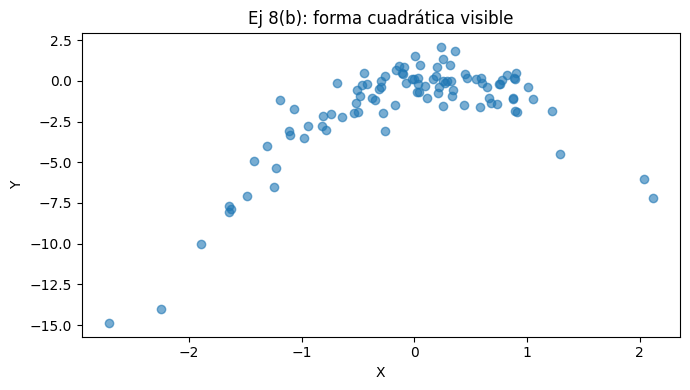

In [20]:
plt.figure(figsize=(7, 4))
plt.scatter(x8, y8, alpha=0.6)
plt.xlabel('X'); plt.ylabel('Y')
plt.title('Ej 8(b): forma cuadrática visible')
plt.tight_layout(); plt.show()

### (c) LOOCV PARA GRADOS 1-4

In [21]:
df8 = pd.DataFrame({'x': x8, 'y': y8})

# grado - grado del polinomio a ajustar (1, 2, 3 o 4)
def loocv_poly(df, grado):
    mse = [] # errores cuadráticos de cada iteración
    for i in range(len(df)): # Itera sobre cada observación (una por vez)
        tr = df.drop(index=i) # DataFrame completo EXCLUYENDO la observación i (n-1 observaciones)
        te = df.iloc[[i]] # Solo la observación i (1 observación) y usa doble corchete [[i]] para mantener formato DataFrame

        # TRAIN
        # [tr['x']**d for d in range(1, grado+1)] - Lista de arrays: [x¹, x², x³, ...]
        # np.column_stack() - Concatena en columnas
        # s tienes grado=2, te arroja columnas [x, x²]
        X_tr_poly_terms = np.column_stack([tr['x']**d for d in range(1, grado+1)])
        X_tr = sm.add_constant(X_tr_poly_terms)

        # TEST
        # te['x'].values[0] - Valor de x de la observación i**d for d in range(1, grado+1) - Calcula potencias
        # .reshape(1, -1) - Convierte en matriz de 1 fila
        X_te_poly_terms = np.array([te['x'].values[0]**d for d in range(1, grado+1)]).reshape(1, -1)
        X_te = np.hstack((np.ones((1, 1)), X_te_poly_terms))
        # np.ones((1, 1)) - Matriz de 1x1 con valor 1 (el intercepto)
        # np.hstack() - Concatena horizontalmente: [constante, x, x², ...]

        # Entrena modelo OLS
        m = sm.OLS(tr['y'], X_tr).fit()
        pred = m.predict(X_te)[0] # Predice el valor de y para la observación i
        mse.append((te['y'].values[0] - pred)**2)
        # te['y'].values[0] - Valor real de y
        # - pred - Diferencia (residuo)
        # **2 - Eleva al cuadrado
        # .append() - Añade a lista de MSEs
    return np.mean(mse) #  MSE promedio de todas las iteraciones LOOCV

print("\n--- (c) LOOCV MSE con seed = 1 ---")
# Calcula MSE para grados 1 a 4 usando diccionarios, osea grado1 = MSE1, grado2 = MSE2 y así ...
mse_c = {d: loocv_poly(df8, d) for d in range(1, 5)}
for d, m in mse_c.items():
    print(f"  Grado {d}: {m:.4f}")


--- (c) LOOCV MSE con seed = 1 ---
  Grado 1: 6.6330
  Grado 2: 1.1229
  Grado 3: 1.3018
  Grado 4: 1.3324


# (d) Se prueba con otra semilla

In [22]:
rng8d = np.random.default_rng(99) # nueva semilla
x8d = rng8d.normal(size=100)
y8d = x8d - 2*x8d**2 + rng8d.normal(size=100) # Genera nuevos valores de Y con el mismo modelo verdadero
df8d = pd.DataFrame({'x': x8d, 'y': y8d}) # crea DataFrame con los nuevos datos

print("\n--- (d) LOOCV MSE con seed=99 ---")
for d in range(1, 5): # Calcula e imprime MSE para grados 1-4 con la nueva semilla
    print(f"  Grado {d}: {loocv_poly(df8d, d):.4f}")


--- (d) LOOCV MSE con seed=99 ---
  Grado 1: 4.5897
  Grado 2: 1.1735
  Grado 3: 1.2251
  Grado 4: 1.3224


### (e) IDENTIFICAR MEJOR MODELO

In [23]:
mejor = min(mse_c, key=mse_c.get) # busca el grado con menor MSE
print(f"\n--- (e) Mejor modelo: Grado {mejor} ---")


--- (e) Mejor modelo: Grado 2 ---


### (f) P-VALUES DE LOS COEFICIENTES

In [24]:
for d in range(1, 5): # ciclo para grados 1 a 4
    X = sm.add_constant(np.column_stack([x8**g for g in range(1, d+1)])) # Construye matriz de predictores con todos los términos hasta grado d
    pvals = sm.OLS(y8, X).fit().pvalues # entrena OLS y extrae p-values de todos los coeficientes
    nombres = ['const'] + [f'X^{g}' for g in range(1, d+1)] # Crea nombres para cada coeficiente: 'const', 'X^1', 'X^2', ...

    for n, p in zip(nombres, pvals): # Imprime cada coeficiente con su p-value e indicador de significancia
        sig = 'SI sig' if p < 0.05 else 'NO sig'
        print(f" {n:8s}: p={p:.4f}  {sig}")

 const   : p=0.0000  SI sig
 X^1     : p=0.0000  SI sig
 const   : p=0.5428  NO sig
 X^1     : p=0.0000  SI sig
 X^2     : p=0.0000  SI sig
 const   : p=0.6345  NO sig
 X^1     : p=0.0000  SI sig
 X^2     : p=0.0000  SI sig
 X^3     : p=0.2872  NO sig
 const   : p=0.4596  NO sig
 X^1     : p=0.0000  SI sig
 X^2     : p=0.0000  SI sig
 X^3     : p=0.6425  NO sig
 X^4     : p=0.0231  SI sig


## EJERCICIO 9 – Bootstrap en Boston (medv)

In [25]:
Boston = load_data('Boston')
medv   = Boston['medv'].values # medv es la variable objetivo (valor medio de viviendas en miles de dólares)
n9     = len(medv)

In [26]:
# Función auxiliar bootstrap
# data - Array de datos (ej: medv)
# func - Función a aplicar (np.mean, np.median, np.percentile)
# B=1000 - Número de muestras bootstrap (por defecto 1000)
# seed=0 - Semilla para reproducibilidad

def boot_se(data, func, B=1000, seed=0):
    rng_b = np.random.default_rng(seed) # Crea generador aleatorio con la semilla especificada
    return np.std([func(rng_b.choice(data, len(data), replace=True))
    # rng_b.choice(data, len(data), replace=True) es la muestra bootstrap: selecciona len(data) elementos CON reemplazo
    # func(...) - Aplica la función (mean, median, etc.) a la muestra bootstrap
    # [for _ in range(B)] - Repite B veces (1000 veces)
    # np.std() - Desviación estándar de las B estimaciones =  error estándar bootstrap
                   for _ in range(B)])

### (a) MEDIA MUESTRAL

In [27]:
# Calcula la media del valor medio de viviendas
mu = np.mean(medv)
print(f"\n--- (a) μ̂ = {mu:.4f} ---")


--- (a) μ̂ = 22.5328 ---


### (b) ERROR ESTÁNDAR ANALÍTICO DE LA MEDIA


In [28]:
# np.std(medv, ddof=1) - Desviación estándar muestral (divide por n-1)
# / np.sqrt(n9) es de la Fórmula: SE = σ / √n
se_a = np.std(medv, ddof=1) / np.sqrt(n9)
print(f"--- (b) SE analítico = {se_a:.4f} ---")

--- (b) SE analítico = 0.4089 ---


### (c) ERROR ESTÁNDAR BOOTSTRAP DE LA MEDIA

In [29]:
# Usa 1000 muestras bootstrap
se_mu = boot_se(medv, np.mean)
print(f"--- (c) SE bootstrap μ̂ = {se_mu:.4f} (vs analítico {se_a:.4f}) ---")
# b y c deben ser muy similares

--- (c) SE bootstrap μ̂ = 0.4125 (vs analítico 0.4089) ---


### (d) INTERVALO DE CONFIANZA 95%

In [30]:
print(f"--- (d) IC 95%: [{mu - 2*se_mu:.4f}, {mu + 2*se_mu:.4f}] ---")

--- (d) IC 95%: [21.7077, 23.3579] ---


### (e) MEDIANA MUESTRAL

In [31]:
med = np.median(medv)
print(f"--- (e) Mediana μ̂_med = {med:.4f} ---")

--- (e) Mediana μ̂_med = 21.2000 ---


### (f) ERROR ESTÁNDAR BOOTSTRAP DE LA MEDIANA

In [32]:
se_med = boot_se(medv, np.median)
print(f"--- (f) SE bootstrap mediana = {se_med:.4f} ---")
# Solo el bootstrap puede darnos este SE

--- (f) SE bootstrap mediana = 0.3694 ---


### (g) PERCENTIL 10 MUESTRAL

In [33]:
p10 = np.percentile(medv, 10)
print(f"--- (g) Percentil 10 μ̂_0.1 = {p10:.4f} ---")
# 10% de las viviendas están por debajo de este valor
# 90% están por encima

--- (g) Percentil 10 μ̂_0.1 = 12.7500 ---


### (h) ERROR ESTÁNDAR BOOTSTRAP DEL PERCENTIL 10

In [34]:
se_p10 = boot_se(medv, lambda x: np.percentile(x, 10)) # lambda x: np.percentile(x, 10) - Función que calcula percentil 10
print(f"--- (h) SE bootstrap percentil 10 = {se_p10:.4f} ---")

# tabla comparativa
print(pd.DataFrame({
    'Estadístico' : ['Media', 'Mediana', 'Percentil 10'],
    'Estimación'  : [round(mu,4), round(med,4), round(p10,4)],
    'SE Bootstrap': [round(se_mu,4), round(se_med,4), round(se_p10,4)]
}).to_string(index=False))

--- (h) SE bootstrap percentil 10 = 0.5035 ---
 Estadístico  Estimación  SE Bootstrap
       Media     22.5328        0.4125
     Mediana     21.2000        0.3694
Percentil 10     12.7500        0.5035


La media del valor de viviendas en Boston es 22.53, mientras que la mediana es 21.20, mostrando un sesgo derecho en la distribución (algunas viviendas muy caras elevan el promedio). El percentil 10 es 12.75, esto indica que el 10% de las viviendas valen ≤ $12,750.

El error estándar bootstrap de la media (0.4125) es casi igual al analítico (0.4089), lo cual valida el método bootstrap. El intervalo de confianza del 95% para la media es [21.71, 23.36].

Bootstrap calcula los errores estándar para estadísticos sin fórmula analítica: la mediana tiene SE = 0.3694 y el percentil 10 tiene SE = 0.5035. Esto demuestra que el bootstrap es una herramienta que permite calcular la incertidumbre de cualquier estadístico.